# Play Tennis Classification using Categorical Naive Bayes

Also compares performance with Decision Tree and Logistic Regression.

**Dataset:** `Lab 8 - Sheet1.csv`  
**Columns:** No, Outlook, Temperature, Humidity, Wind, Play Tennis

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

## Step 1: Load the dataset

In [2]:
df = pd.read_csv("Lab 8 - Sheet1.csv")

# The "No" column is just a row index, drop it
df = df.drop(columns=["No"])

print(f"Shape: {df.shape}")
df.head()

Shape: (50, 5)


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


## Step 2: Separate input features (X) and target variable (y)

In [3]:
feature_cols = ["Outlook", "Temperature", "Humidity", "Wind"]
target_col = "Play Tennis"

X = df[feature_cols]
y = df[target_col]

## Step 3: Encode categorical values into numerical values

`CategoricalNB` (and `DecisionTreeClassifier`, which is not distance based) work naturally with integer-coded categories, so `OrdinalEncoder` is the appropriate choice for them. We keep one shared ordinal encoding of the features so all three models are trained/tested on identical folds and encodings for a fair comparison.

In [4]:
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)
X_encoded = pd.DataFrame(X_encoded, columns=feature_cols)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # No -> 0, Yes -> 1

print("Encoded Features (first 5 rows)")
display(X_encoded.head())

print("\nEncoder categories (per feature):")
for col, cats in zip(feature_cols, encoder.categories_):
    print(f"  {col}: {list(cats)}")

Encoded Features (first 5 rows)


,Outlook,Temperature,Humidity,Wind
0,2.0,1.0,0.0,1.0
1,2.0,1.0,0.0,0.0
2,0.0,1.0,0.0,1.0
3,1.0,2.0,0.0,1.0
4,1.0,0.0,1.0,1.0



Encoder categories (per feature):
  Outlook: ['Overcast', 'Rain', 'Sunny']
  Temperature: ['Cool', 'Hot', 'Mild']
  Humidity: ['High', 'Normal']
  Wind: ['Strong', 'Weak']


## Step 4: Train / test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 35, Testing samples: 15


## Step 5: Train Categorical Naive Bayes model

In [6]:
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 0., ...., 6., 8.]]), array([[ 5., ...., 6., 10.]]), array([[ 9., ... [ 7., 17.]]), array([[ 7., ... [11., 13.]])]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[11.,24.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-1.16,-0.38]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.63...-1.09861229]]), array([[-0.84...-0.89794159]]), array([[-0.26...-0.36772478]]), array([[-0.48...-0.61903921]])]"


## Step 6: Predict class labels for the test dataset

In [7]:
y_pred_nb = nb_model.predict(X_test)
y_pred_nb

array([1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

## Step 7: Accuracy, confusion matrix, classification report

In [8]:
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy: {acc_nb:.4f}")

cm_nb = confusion_matrix(y_test, y_pred_nb)
print("\nConfusion Matrix:")
print(cm_nb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))

Accuracy: 0.8667

Confusion Matrix:
[[ 3  2]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.60      0.75         5
         Yes       0.83      1.00      0.91        10

    accuracy                           0.87        15
   macro avg       0.92      0.80      0.83        15
weighted avg       0.89      0.87      0.86        15



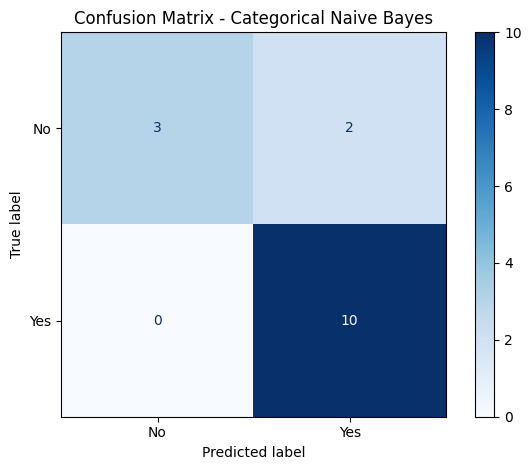

In [9]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Categorical Naive Bayes")
plt.tight_layout()
plt.show()

## Step 8: Predict a new/unseen weather condition

Outlook: Sunny, Temperature: Cool, Humidity: High, Wind: Strong

In [10]:
new_sample = pd.DataFrame({
    "Outlook": ["Sunny"],
    "Temperature": ["Cool"],
    "Humidity": ["High"],
    "Wind": ["Strong"],
})

new_encoded = pd.DataFrame(encoder.transform(new_sample), columns=feature_cols)
new_pred = nb_model.predict(new_encoded)
new_proba = nb_model.predict_proba(new_encoded)

predicted_label = label_encoder.inverse_transform(new_pred)[0]

print(new_sample.to_string(index=False))
print(f"\nPredicted class: {predicted_label}")
print("\nClass probabilities:")
for cls, prob in zip(label_encoder.classes_, new_proba[0]):
    print(f"  {cls}: {prob:.4f}")

Outlook Temperature Humidity   Wind
  Sunny        Cool     High Strong

Predicted class: No

Class probabilities:
  No: 0.7466
  Yes: 0.2534


## Step 9: Compare with Decision Tree and Logistic Regression

Trees split on raw feature values, so ordinal-encoded categories work fine. Logistic Regression assumes numeric magnitude/order matters, so it is fairer to one-hot encode the categories for it specifically.

In [11]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# Logistic Regression pipeline with one-hot encoding, built from the raw
# categorical columns using the exact same row split as X_train/X_test
X_train_raw = X.loc[X_train.index]
X_test_raw = X.loc[X_test.index]

log_reg_pipeline = Pipeline(steps=[
    ("onehot", ColumnTransformer(
        transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols)]
    )),
    ("clf", LogisticRegression(max_iter=1000)),
])

log_reg_pipeline.fit(X_train_raw, y_train)
y_pred_lr = log_reg_pipeline.predict(X_test_raw)
acc_lr = accuracy_score(y_test, y_pred_lr)

# New sample prediction with the other two models (for reference)
dt_new_pred = label_encoder.inverse_transform(dt_model.predict(new_encoded))[0]
lr_new_pred = label_encoder.inverse_transform(log_reg_pipeline.predict(new_sample))[0]

comparison = pd.DataFrame({
    "Model": ["Categorical Naive Bayes", "Decision Tree", "Logistic Regression"],
    "Accuracy": [acc_nb, acc_dt, acc_lr],
    "Prediction for new sample": [predicted_label, dt_new_pred, lr_new_pred],
})
comparison

,Model,Accuracy,Prediction for new sample
0,Categorical Naive Bayes,0.866667,No
1,Decision Tree,1.000000,No
2,Logistic Regression,0.933333,No


In [12]:
print("Decision Tree - Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

print("Logistic Regression - Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

Decision Tree - Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         5
         Yes       1.00      1.00      1.00        10

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.80      0.89         5
         Yes       0.91      1.00      0.95        10

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



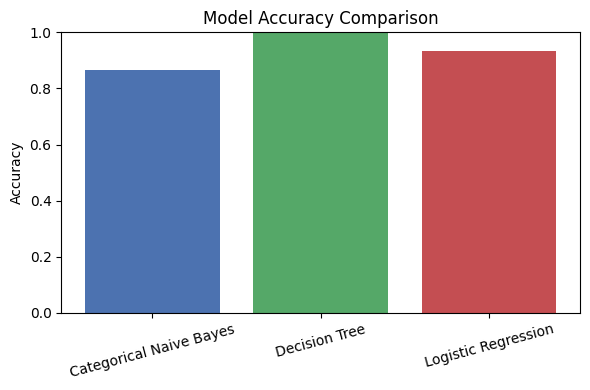

In [13]:
plt.figure(figsize=(6, 4))
plt.bar(comparison["Model"], comparison["Accuracy"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()